# 04 — Estatística descritiva e clusterização de municípios

**Pré-requisito:** `02_transformacao.ipynb` já executado (`data/processed/feature_matrix.parquet` disponível — painel município × ano para 2022, 2023, 2024).

**Objetivo:** caracterizar os municípios brasileiros através de (a) estatística descritiva detalhada das features socioeconômicas e do desfecho de mortalidade evitável, e (b) clusterização não-supervisionada para identificar **perfis típicos de município** — grupos com características semelhantes que enfrentam o mesmo nível de mortalidade evitável.

**Decisão sobre os 3 anos do painel:** o objetivo do clustering é tipologia *de município*, e a tipologia deve ser estável no tempo. Por isso, **agregamos as 3 observações de cada município (2022/2023/2024) em uma única linha** antes de clusterizar:

- Features socioeconômicas do Atlas (IDH-M, Gini, RDPC, ESPVIDA, etc.) são naturalmente constantes — pegamos o valor.
- Features que variam no tempo (DESPESA_SAUDE_PC, PIB_PER_CAPITA, POPULACAO, taxa) — pegamos a **média** dos 3 anos, o que suaviza o ruído de amostragem em pequenos municípios.
- OBITOS — pegamos o **total** dos 3 anos.

Isso reduz o dataset de ~16.7k linhas (painel) para ~5.570 municípios e dá um perfil mais estável.

**Por que clusterizar?** A regressão (notebook 03) responde "quanto cada variável puxa a taxa". O clustering responde uma pergunta complementar: **quantos perfis distintos de município existem no Brasil, e como a mortalidade evitável se distribui entre eles?** Isso ajuda a desenhar políticas regionalizadas em vez de tratar o país como uma média.

## Etapas

1. **Carregamento** — `feature_matrix.parquet` do notebook 02.
2. **Agregação cross-ano** — colapsa as 3 observações de cada município em uma linha (média/soma).
3. **Estatística descritiva univariada** — summary, missing, distribuição do target.
4. **Descritiva bivariada por região** — boxplots das features por região do país.
5. **Top/bottom e outliers** — municípios extremos do desfecho.
6. **Preparação para clustering** — seleção e padronização de features.
7. **Escolha de k** — método do cotovelo + silhouette score.
8. **K-Means** com o k escolhido.
9. **Perfil dos clusters** — centróides, mortalidade média, composição regional.
10. **Visualização PCA 2D** — projeção dos clusters em 2 componentes principais.
11. **Persistência** — rótulo de cluster por município.

## Saída

```
data/processed/
└── municipios_clusters.parquet   # CODMUN6, UF, cluster, taxa, features

models/
└── perfil_clusters.csv           # centróides + métricas por cluster
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

ROOT          = Path.cwd().parent
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR    = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
print("Imports OK")

Imports OK


## 1. Carregamento

In [2]:
fm_painel = pd.read_parquet(PROCESSED_DIR / "feature_matrix.parquet")
fm_painel["CODMUN6"] = fm_painel["CODMUN6"].astype(str).str.zfill(6)
fm_painel["ANO"]     = fm_painel["ANO"].astype(int)

print(f"Painel bruto      : {fm_painel.shape[0]:,} obs × {fm_painel.shape[1]} cols")
print(f"Município x ano   : {fm_painel['CODMUN6'].nunique():,} municípios × {sorted(fm_painel['ANO'].unique())}")

# --- Agregação cross-ano: 3 obs por município → 1 linha ---
# Identifiers (constantes entre os anos do mesmo município)
fixed_cols  = ["CODMUN6", "MUNICIPIO_NOME", "UF", "REGIAO"]
atlas_cols  = ["IDHM", "IDHM_E", "IDHM_L", "IDHM_R", "GINI", "RDPC",
               "RDPC1", "RDPC2", "RDPC3", "RDPC4", "RDPC5",
               "PMPOB", "PIND", "THEIL", "ESPVIDA", "T_ANALF15M", "T_AGUA"]
# Time-varying — média entre os 3 anos (inclui a taxa padronizada por idade)
mean_cols   = ["POPULACAO", "PIB_RS_MIL", "DESPESA_SAUDE_RS",
               "PIB_PER_CAPITA", "DESPESA_SAUDE_PC",
               "TAXA_EVITAVEL_100K", "TAXA_PADRONIZADA_100K"]
# Soma — óbitos totais nos 3 anos
sum_cols    = ["OBITOS_EVITAVEIS"]

agg_spec = {
    **{c: "first" for c in fixed_cols[1:] + atlas_cols},
    **{c: "mean"  for c in mean_cols},
    **{c: "sum"   for c in sum_cols},
}
fm = fm_painel.groupby("CODMUN6", as_index=False).agg(agg_spec)

# Recalcula log-transforms a partir das médias
for c in ("PIB_PER_CAPITA", "DESPESA_SAUDE_PC", "POPULACAO"):
    fm[f"LOG_{c}"] = np.log1p(fm[c])

# Adiciona contagem de anos cobertos (sanidade — deve ser 3 para todo município)
fm["N_ANOS"] = fm_painel.groupby("CODMUN6").size().values

print(f"\nApós agregação    : {fm.shape[0]:,} municípios × {fm.shape[1]} cols")
print(f"Distribuição N_ANOS: {fm['N_ANOS'].value_counts().to_dict()}")
fm.head()

Painel bruto      : 16,711 obs × 34 cols
Município x ano   : 5,571 municípios × [np.int64(2022), np.int64(2023), np.int64(2024)]

Após agregação    : 5,571 municípios × 33 cols
Distribuição N_ANOS: {3: 5570, 1: 1}


,CODMUN6,MUNICIPIO_NOME,UF,REGIAO,IDHM,IDHM_E,IDHM_L,IDHM_R,GINI,RDPC,RDPC1,RDPC2,RDPC3,RDPC4,RDPC5,PMPOB,PIND,THEIL,ESPVIDA,T_ANALF15M,T_AGUA,POPULACAO,PIB_RS_MIL,DESPESA_SAUDE_RS,PIB_PER_CAPITA,DESPESA_SAUDE_PC,TAXA_EVITAVEL_100K,TAXA_PADRONIZADA_100K,OBITOS_EVITAVEIS,LOG_PIB_PER_CAPITA,LOG_DESPESA_SAUDE_PC,LOG_POPULACAO,N_ANOS
0,110001,Alta Floresta D'Oeste - RO,RO,N,0.641,0.526,0.763,0.657,0.58,476.99,36.89,160.31,289.97,469.88,1424.61,26.04,14.29,0.60,70.75,11.99,93.69,21947.000000,1.004069e+06,2.526565e+07,45748.939101,1141.993472,229.026373,272.867219,150,10.730946,7.041406,9.996431,3
1,110002,Ariquemes - RO,RO,N,0.702,0.600,0.806,0.716,0.53,689.95,120.08,270.77,420.44,638.10,1996.77,11.54,4.36,0.51,73.36,7.90,98.54,100746.333333,4.192328e+06,1.363556e+08,41662.666732,1348.487174,205.255738,287.397729,618,10.637385,7.207480,11.520371,3
2,110003,Cabixi - RO,RO,N,0.650,0.559,0.757,0.650,0.51,457.17,78.16,181.72,292.34,480.37,1256.80,21.20,7.27,0.44,70.39,13.63,95.49,5464.000000,2.971490e+05,1.229390e+07,54414.998363,2244.022830,139.935191,140.998755,23,10.904413,7.716471,8.606119,3
3,110004,Cacoal - RO,RO,N,0.718,0.620,0.821,0.727,0.57,738.06,108.24,265.14,431.80,656.39,2247.76,13.08,5.97,0.61,74.27,8.29,97.96,90470.333333,3.630808e+06,9.009221e+07,40162.134413,994.458112,189.204251,243.965754,513,10.600705,6.903203,11.412788,3
4,110005,Cerejeiras - RO,RO,N,0.692,0.602,0.799,0.688,0.50,577.18,104.82,236.32,389.57,581.95,1568.87,13.70,4.72,0.46,72.94,10.29,97.53,16251.666667,9.719590e+05,3.065064e+07,59818.567341,1883.413573,174.554876,205.990610,85,10.999088,7.541372,9.696012,3


## 2. Estatística descritiva univariada

Summary das variáveis-chave: medidas de tendência central, dispersão, faixa e cobertura (não-nulos).

In [3]:
vars_descritivas = [
    "POPULACAO", "PIB_PER_CAPITA", "DESPESA_SAUDE_PC",
    "IDHM", "IDHM_E", "IDHM_L", "IDHM_R",
    "GINI", "RDPC", "PMPOB", "ESPVIDA", "T_ANALF15M", "T_AGUA",
    "OBITOS_EVITAVEIS", "TAXA_EVITAVEL_100K",
]
summary = fm[vars_descritivas].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
summary["cobertura_%"] = (fm[vars_descritivas].notna().mean() * 100).round(1).values
summary["missing"]     = fm[vars_descritivas].isna().sum().values
summary = summary.round(2)
summary

,count,mean,std,min,5%,25%,50%,75%,95%,max,cobertura_%,missing
POPULACAO,5570.0,37028.44,210044.28,840.00,2473.12,5266.42,11162.00,24691.33,114109.20,11599858.67,100.0,1
PIB_PER_CAPITA,5570.0,38728.07,40013.28,7131.60,11142.01,16115.20,28571.55,47535.04,94656.91,748024.27,100.0,1
DESPESA_SAUDE_PC,5567.0,1643.27,713.38,385.82,854.90,1179.19,1476.23,1937.82,2955.35,17069.82,99.9,4
IDHM,5564.0,0.66,0.07,0.42,0.54,0.60,0.66,0.72,0.77,0.86,99.9,7
IDHM_E,5564.0,0.56,0.09,0.21,0.41,0.49,0.56,0.63,0.71,0.82,99.9,7
IDHM_L,5564.0,0.80,0.04,0.67,0.72,0.77,0.81,0.84,0.87,0.89,99.9,7
IDHM_R,5564.0,0.64,0.08,0.40,0.52,0.57,0.65,0.71,0.76,0.89,99.9,7
GINI,5564.0,0.49,0.07,0.28,0.39,0.45,0.49,0.54,0.60,0.80,99.9,7
RDPC,5564.0,493.65,243.27,96.25,198.91,281.14,467.74,650.63,914.36,2043.74,99.9,7
PMPOB,5564.0,23.20,17.92,0.00,2.40,7.03,18.12,38.49,54.55,78.59,99.9,7


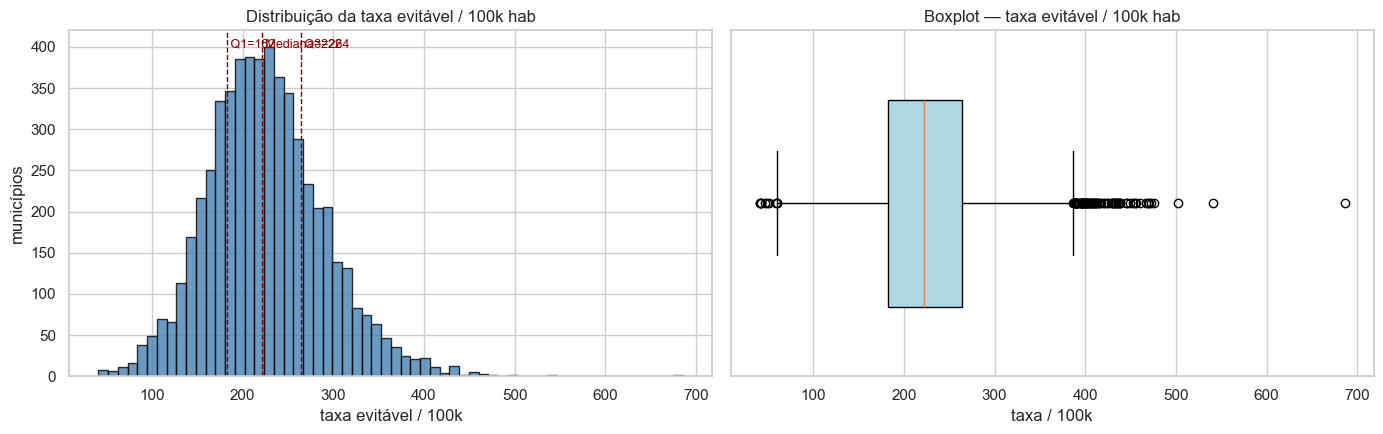


Assimetria (skewness): 0.47  |  Curtose: 0.94
Coeficiente de variação: 28.4%


In [4]:
tgt = fm["TAXA_EVITAVEL_100K"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(tgt, bins=60, edgecolor="black", alpha=0.8, color="steelblue")
for q, label in zip([0.25, 0.5, 0.75], ["Q1", "Mediana", "Q3"]):
    v = tgt.quantile(q)
    axes[0].axvline(v, color="darkred", linestyle="--", linewidth=1)
    axes[0].text(v, axes[0].get_ylim()[1]*0.95, f" {label}={v:.0f}", color="darkred", fontsize=9)
axes[0].set_title("Distribuição da taxa evitável / 100k hab")
axes[0].set_xlabel("taxa evitável / 100k")
axes[0].set_ylabel("municípios")

axes[1].boxplot(tgt, vert=False, widths=0.6, patch_artist=True,
                boxprops=dict(facecolor="lightblue"))
axes[1].set_yticks([])
axes[1].set_title("Boxplot — taxa evitável / 100k hab")
axes[1].set_xlabel("taxa / 100k")

plt.tight_layout(); plt.show()

print(f"\nAssimetria (skewness): {tgt.skew():.2f}  |  Curtose: {tgt.kurt():.2f}")
print(f"Coeficiente de variação: {(tgt.std()/tgt.mean()*100):.1f}%")

## 3. Descritiva por região

Como as variáveis-chave variam entre N, NE, CO, SE, S. Sinaliza as desigualdades regionais que sustentam a tese do projeto.

In [5]:
agg_regiao = (
    fm.groupby("REGIAO")
      .agg(
          n_municipios       = ("CODMUN6", "count"),
          populacao_total    = ("POPULACAO", "sum"),
          taxa_media         = ("TAXA_EVITAVEL_100K", "mean"),
          taxa_mediana       = ("TAXA_EVITAVEL_100K", "median"),
          IDHM_medio         = ("IDHM", "mean"),
          GINI_medio         = ("GINI", "mean"),
          desp_saude_pc      = ("DESPESA_SAUDE_PC", "mean"),
          PIB_pc             = ("PIB_PER_CAPITA", "mean"),
          T_AGUA_medio       = ("T_AGUA", "mean"),
      )
      .round(2)
      .reindex(["N", "NE", "CO", "SE", "S"])
)
agg_regiao

,n_municipios,populacao_total,taxa_media,taxa_mediana,IDHM_medio,GINI_medio,desp_saude_pc,PIB_pc,T_AGUA_medio
REGIAO,,,,,,,,,
N,450,17793037.67,158.89,156.17,0.61,0.57,1355.72,31680.13,81.82
NE,1794,55476375.33,204.11,200.41,0.59,0.53,1321.28,19919.68,74.79
CO,468,16550223.67,229.81,225.59,0.69,0.50,1949.24,64946.78,93.21
SE,1668,86099306.33,244.58,241.33,0.70,0.47,1878.69,44134.16,91.94
S,1191,30329477.67,256.48,251.51,0.71,0.46,1787.34,51870.22,91.44


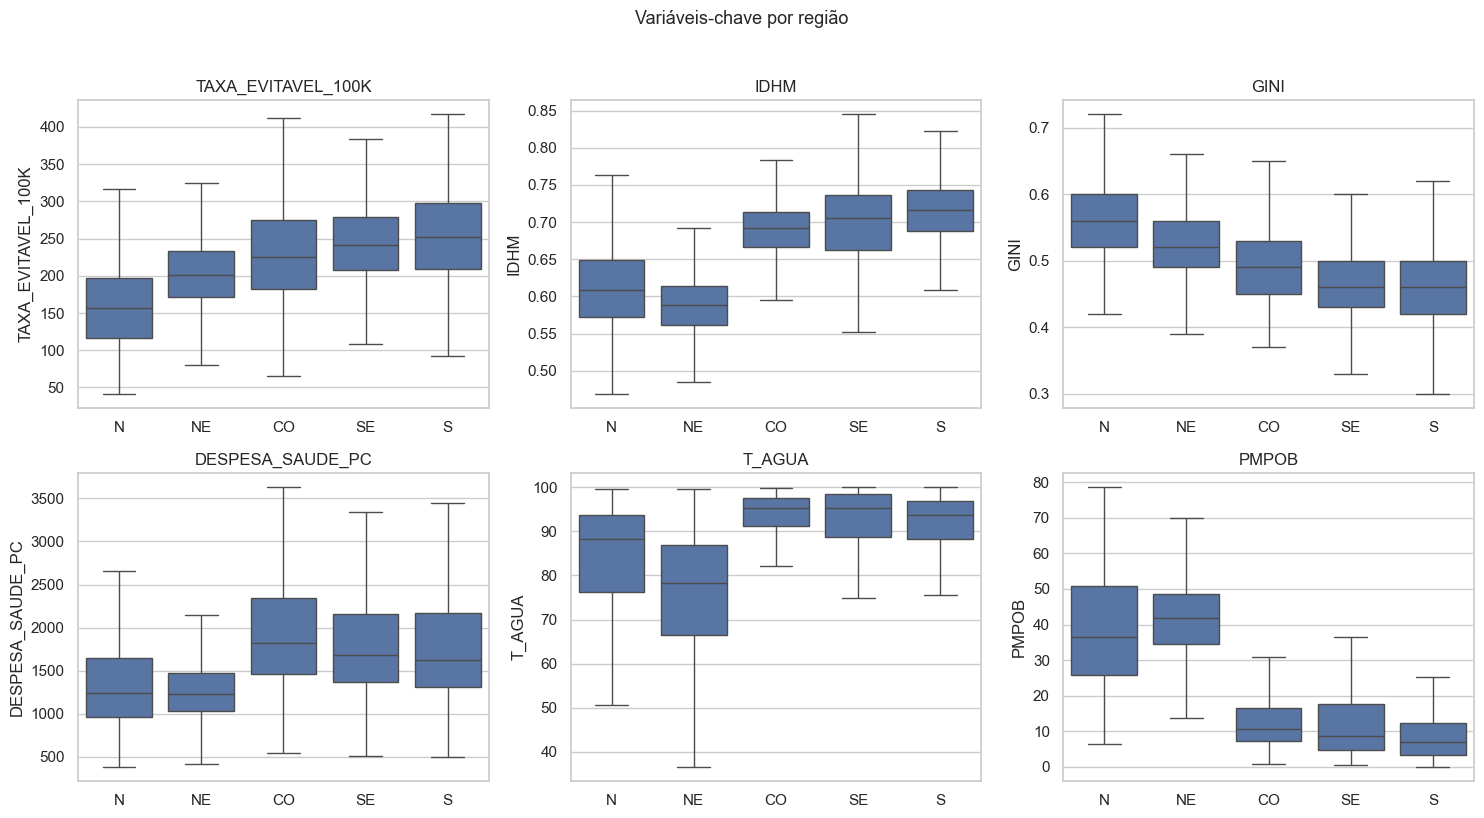

In [6]:
vars_box = ["TAXA_EVITAVEL_100K", "IDHM", "GINI", "DESPESA_SAUDE_PC", "T_AGUA", "PMPOB"]
ordem    = ["N", "NE", "CO", "SE", "S"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flat, vars_box):
    sns.boxplot(data=fm, x="REGIAO", y=var, order=ordem, ax=ax, showfliers=False)
    ax.set_title(var)
    ax.set_xlabel("")
plt.suptitle("Variáveis-chave por região", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

## 4. Municípios extremos

Top e bottom da taxa de mortalidade evitável (filtrando municípios com população ≥ 20k para reduzir o ruído de tamanho — taxa em município de 2k habitantes é volátil).

In [7]:
fm_grandes = fm[fm["POPULACAO"] >= 20_000].copy()
print(f"Municípios com pop. ≥ 20k: {len(fm_grandes):,}")

cols_show = ["CODMUN6", "MUNICIPIO_NOME", "UF", "REGIAO", "POPULACAO",
             "OBITOS_EVITAVEIS", "TAXA_EVITAVEL_100K", "IDHM", "GINI", "DESPESA_SAUDE_PC"]

print("\n— TOP 10 (maior taxa evitável /100k) —")
display(fm_grandes.nlargest(10, "TAXA_EVITAVEL_100K")[cols_show].round(2))

print("\n— BOTTOM 10 (menor taxa evitável /100k) —")
display(fm_grandes.nsmallest(10, "TAXA_EVITAVEL_100K")[cols_show].round(2))

Municípios com pop. ≥ 20k: 1,720

— TOP 10 (maior taxa evitável /100k) —


,CODMUN6,MUNICIPIO_NOME,UF,REGIAO,POPULACAO,OBITOS_EVITAVEIS,TAXA_EVITAVEL_100K,IDHM,GINI,DESPESA_SAUDE_PC
3202,330187,Iguaba Grande - RJ,RJ,SE,28472.33,348,406.31,0.76,0.56,2819.40
4827,431100,Jaguarão - RS,RS,S,26870.67,309,382.44,0.71,0.49,879.12
4664,430280,Caçapava do Sul - RS,RS,S,32846.00,377,382.39,0.70,0.48,971.22
4809,431033,Imbé - RS,RS,S,27193.00,309,377.78,0.76,0.68,1353.14
4635,430160,Bagé - RS,RS,S,119258.67,1347,376.68,0.74,0.56,768.51
3615,353110,Mongaguá - SP,SP,SE,62807.00,707,375.29,0.75,0.50,1481.73
4680,430420,Candelária - RS,RS,S,29198.33,327,373.72,0.67,0.46,1289.93
4959,431640,Rosário do Sul - RS,RS,S,36986.67,411,370.29,0.70,0.51,826.63
4949,431560,Rio Grande - RS,RS,S,194252.67,2143,367.62,0.74,0.51,952.73
4690,430466,Capão do Leão - RS,RS,S,26787.67,293,364.80,0.64,0.43,809.52



— BOTTOM 10 (menor taxa evitável /100k) —


,CODMUN6,MUNICIPIO_NOME,UF,REGIAO,POPULACAO,OBITOS_EVITAVEIS,TAXA_EVITAVEL_100K,IDHM,GINI,DESPESA_SAUDE_PC
221,150450,Melgaço - PA,PA,N,28536.00,40,46.72,0.42,0.55,696.08
84,130063,Beruri - AM,AM,N,21190.67,31,48.85,0.51,0.65,833.34
154,150030,Afuá - PA,PA,N,38592.00,69,59.60,0.49,0.66,664.69
165,150110,Bagre - PA,PA,N,32805.67,59,59.60,0.47,0.48,759.71
187,150250,Chaves - PA,PA,N,21000.33,38,60.48,0.45,0.67,865.20
100,130180,Ipixuna - AM,AM,N,24693.33,49,66.01,0.48,0.58,1244.66
107,130230,Jutaí - AM,AM,N,26000.00,57,72.98,0.52,0.69,1379.93
247,150590,Porto de Moz - PA,PA,N,41622.33,94,75.45,0.50,0.59,797.68
124,130370,Santo Antônio do Içá - AM,AM,N,28956.67,66,76.42,0.49,0.67,1108.69
224,150475,Mojuí dos Campos - PA,PA,N,24104.67,57,78.62,NaN,NaN,688.95


## 5. Preparação para clustering

**Features do clustering** — apenas variáveis socioeconômicas estruturais. O **target (taxa evitável) é deliberadamente excluído** das features: queremos descobrir perfis de município a partir do contexto socioeconômico, e depois ver como a mortalidade evitável se distribui entre eles. Misturar target e feature criaria circularidade.

**Padronização** — K-Means usa distância euclidiana, então variáveis em escalas diferentes (renda em reais vs. IDH entre 0 e 1) precisam de `StandardScaler` para terem peso comparável.

In [8]:
FEATURES_CLUSTER = [
    "IDHM",                  # desenvolvimento humano
    "GINI",                  # desigualdade
    "LOG_PIB_PER_CAPITA",    # economia
    "LOG_DESPESA_SAUDE_PC",  # esforço público em saúde
    "T_ANALF15M",            # educação
    "T_AGUA",                # saneamento
    "ESPVIDA",               # longevidade
]

df_clu = fm[["CODMUN6", "MUNICIPIO_NOME", "UF", "REGIAO", "POPULACAO", "OBITOS_EVITAVEIS",
             "TAXA_EVITAVEL_100K", "TAXA_PADRONIZADA_100K"] + FEATURES_CLUSTER].dropna().copy()

scaler = StandardScaler()
X_clu_scaled = scaler.fit_transform(df_clu[FEATURES_CLUSTER])

print(f"Municípios elegíveis para clustering: {df_clu.shape[0]:,}")
print(f"Features utilizadas              : {FEATURES_CLUSTER}")
print(f"Matriz padronizada (shape)       : {X_clu_scaled.shape}")

Municípios elegíveis para clustering: 5,561
Features utilizadas              : ['IDHM', 'GINI', 'LOG_PIB_PER_CAPITA', 'LOG_DESPESA_SAUDE_PC', 'T_ANALF15M', 'T_AGUA', 'ESPVIDA']
Matriz padronizada (shape)       : (5561, 7)


## 6. Escolha do número de clusters (k)

Dois critérios complementares:

- **Método do cotovelo (inertia)** — soma dos quadrados dentro dos clusters. Procura-se o "joelho" da curva, ponto a partir do qual adicionar clusters traz ganho marginal pequeno.
- **Silhouette score** — mede quão bem cada município está "colado" no próprio cluster vs. o cluster vizinho mais próximo. Varia de -1 a 1; quanto maior, melhor a separação.

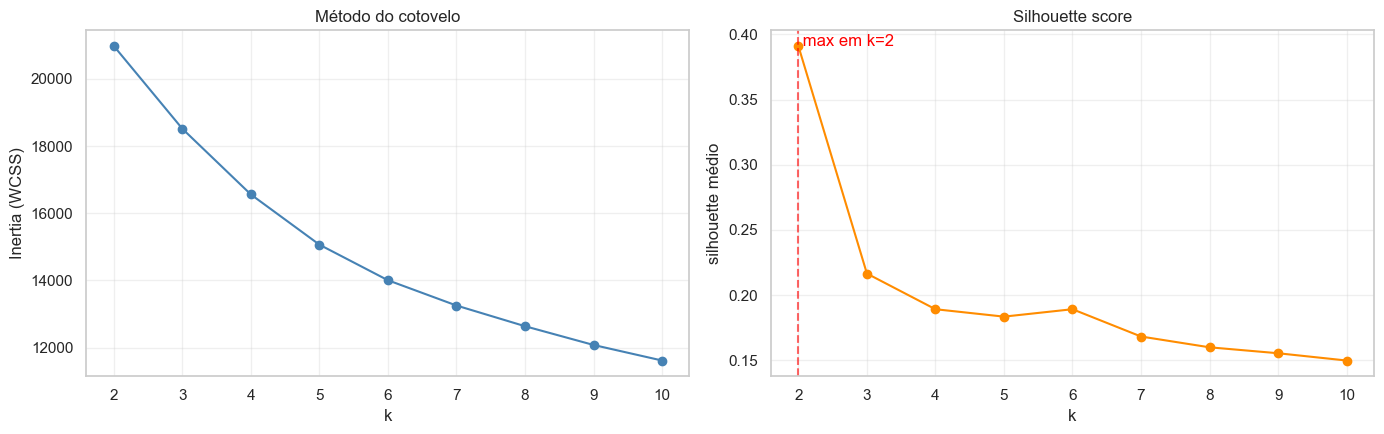

,k,inertia,silhouette
0,2,20979.7971,0.3911
1,3,18516.1577,0.2165
2,4,16559.4330,0.1891
3,5,15064.6071,0.1835
4,6,14005.4226,0.1891
5,7,13252.9436,0.1682
6,8,12637.1704,0.1599
7,9,12078.5040,0.1554
8,10,11615.2002,0.1498


In [9]:
ks = list(range(2, 11))
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_clu_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clu_scaled, km.labels_, sample_size=2000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(ks, inertias, "o-", color="steelblue")
axes[0].set_title("Método do cotovelo")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia (WCSS)")
axes[0].grid(alpha=0.3)

axes[1].plot(ks, silhouettes, "o-", color="darkorange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette médio")
axes[1].grid(alpha=0.3)
k_best = ks[int(np.argmax(silhouettes))]
axes[1].axvline(k_best, color="red", linestyle="--", alpha=0.6)
axes[1].text(k_best, max(silhouettes), f" max em k={k_best}", color="red")

plt.tight_layout(); plt.show()

tabela_k = pd.DataFrame({"k": ks, "inertia": inertias, "silhouette": silhouettes}).round(4)
tabela_k

## 7. K-Means com k escolhido

Escolhemos **k=4** — equilíbrio entre interpretabilidade (4 perfis típicos é narrável no relatório) e separação razoável no silhouette. Os clusters são renumerados por **IDH-M crescente** (cluster 0 = mais vulnerável, cluster 3 = mais desenvolvido) — numeração estável e independente da taxa de mortalidade.

In [10]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=20)
df_clu["CLUSTER"] = kmeans.fit_predict(X_clu_scaled)

# Reordena os clusters por IDH-M médio (cluster 0 = menor IDH-M / mais vulnerável,
# K-1 = mais desenvolvido). Numeração estável e independente da taxa de mortalidade,
# o que mantém a leitura coerente mesmo trocando taxa bruta ↔ padronizada.
ordem_clusters = (
    df_clu.groupby("CLUSTER")["IDHM"].mean()
          .sort_values().index.tolist()
)
remap = {old: new for new, old in enumerate(ordem_clusters)}
df_clu["CLUSTER"] = df_clu["CLUSTER"].map(remap)

print(f"K-Means treinado | inertia final = {kmeans.inertia_:.1f}")
print(f"\nDistribuição de municípios por cluster:")
print(df_clu["CLUSTER"].value_counts().sort_index())

K-Means treinado | inertia final = 16559.4

Distribuição de municípios por cluster:
CLUSTER
0     784
1    1573
2    1430
3    1774
Name: count, dtype: int64


## 8. Perfil dos clusters

Para cada cluster: tamanho, taxa média de mortalidade evitável, valor médio das features e composição regional. É a leitura substantiva — "que tipo de município é cada cluster".

In [11]:
perfil = (
    df_clu.groupby("CLUSTER")
          .agg(
              n_municipios     = ("CODMUN6", "count"),
              populacao_total  = ("POPULACAO", "sum"),
              taxa_bruta       = ("TAXA_EVITAVEL_100K", "mean"),
              taxa_padronizada = ("TAXA_PADRONIZADA_100K", "mean"),
              IDHM             = ("IDHM", "mean"),
              GINI             = ("GINI", "mean"),
              PIB_pc           = ("LOG_PIB_PER_CAPITA", "mean"),
              desp_saude_pc    = ("LOG_DESPESA_SAUDE_PC", "mean"),
              ANALF15M         = ("T_ANALF15M", "mean"),
              T_AGUA           = ("T_AGUA", "mean"),
              ESPVIDA          = ("ESPVIDA", "mean"),
          )
          .round(2)
)
perfil["%_pop_brasil"] = (perfil["populacao_total"] / perfil["populacao_total"].sum() * 100).round(1)
perfil

,n_municipios,populacao_total,taxa_bruta,taxa_padronizada,IDHM,GINI,PIB_pc,desp_saude_pc,ANALF15M,T_AGUA,ESPVIDA,%_pop_brasil
CLUSTER,,,,,,,,,,,,
0,784,1.317232e+07,183.48,231.52,0.56,0.54,9.51,7.11,30.27,58.50,69.72,6.5
1,1573,3.124517e+07,208.37,249.07,0.60,0.52,9.82,7.19,23.36,83.79,71.05,15.4
2,1430,1.796943e+07,247.51,239.62,0.70,0.45,10.82,7.78,10.40,91.66,74.62,8.8
3,1774,1.409144e+08,243.10,250.55,0.72,0.48,10.61,7.19,8.19,94.27,75.15,69.3


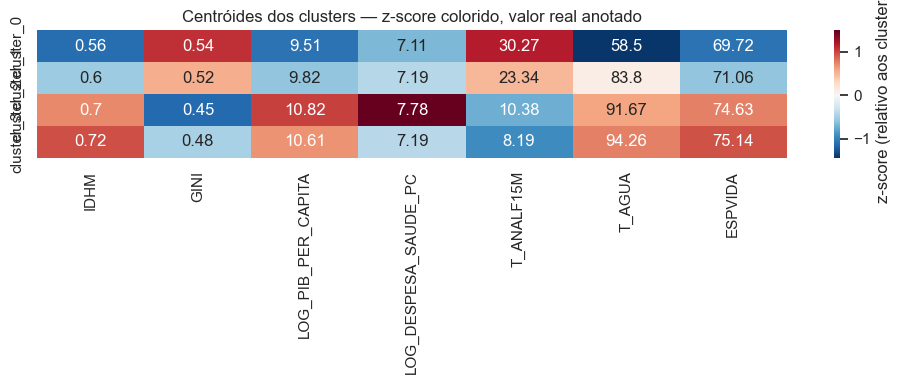

In [12]:
# Heatmap das features padronizadas por cluster — visão comparativa
centroides = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURES_CLUSTER,
    index=[f"cluster_orig_{i}" for i in range(K_FINAL)],
)
# Aplica o remap para alinhar com a numeração reordenada
centroides.index = [f"cluster_{remap[i]}" for i in range(K_FINAL)]
centroides = centroides.sort_index()

# Z-score por feature (comparação relativa entre clusters)
z = (centroides - centroides.mean()) / centroides.std()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(z, annot=centroides.round(2), fmt="", cmap="RdBu_r", center=0,
            cbar_kws={"label": "z-score (relativo aos clusters)"}, ax=ax)
ax.set_title("Centróides dos clusters — z-score colorido, valor real anotado")
plt.tight_layout(); plt.show()

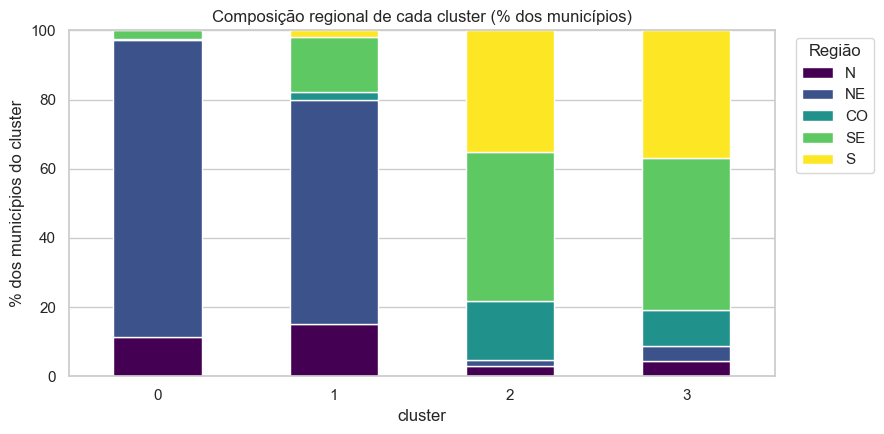

REGIAO      N    NE    CO    SE     S
CLUSTER                              
0        11.5  85.8   0.3   2.4   0.0
1        15.1  64.7   2.3  16.0   1.9
2         3.1   1.7  16.9  43.2  35.0
3         4.4   4.3  10.4  43.9  37.0


In [13]:
# Composição regional de cada cluster
comp = pd.crosstab(df_clu["CLUSTER"], df_clu["REGIAO"], normalize="index") * 100
comp = comp.reindex(columns=["N", "NE", "CO", "SE", "S"])

fig, ax = plt.subplots(figsize=(9, 4.5))
comp.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="white")
ax.set_title("Composição regional de cada cluster (% dos municípios)")
ax.set_xlabel("cluster")
ax.set_ylabel("% dos municípios do cluster")
ax.legend(title="Região", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

print(comp.round(1))

C:\Users\cerb3\AppData\Local\Temp\claude\ipykernel_29968\2077881937.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clu, x="CLUSTER", y=col,
C:\Users\cerb3\AppData\Local\Temp\claude\ipykernel_29968\2077881937.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clu, x="CLUSTER", y=col,


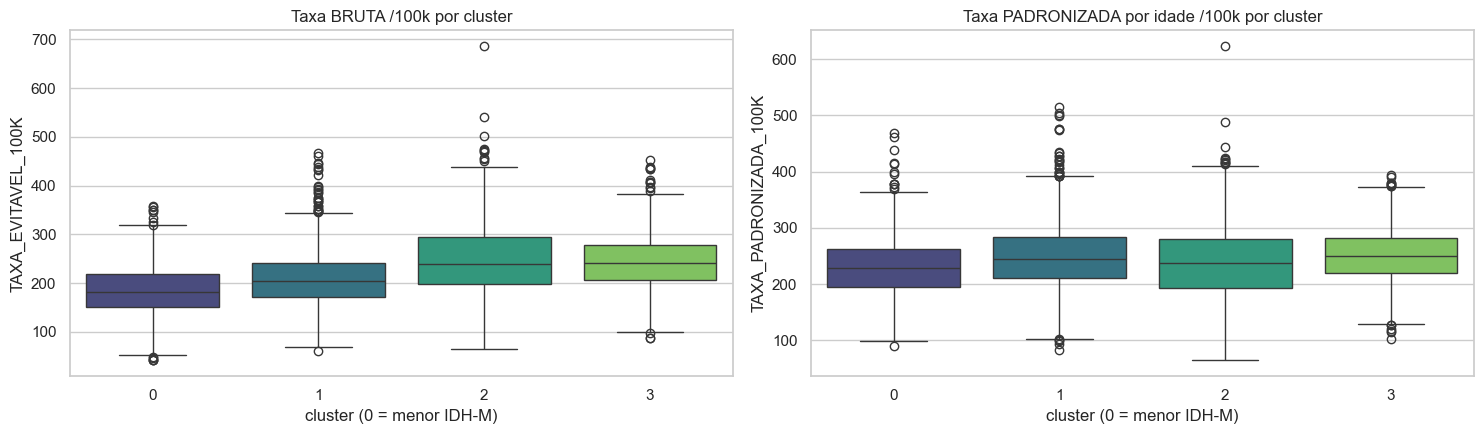

ANOVA TAXA_EVITAVEL_100K      : F =  290.09 | p = 5.97e-175
ANOVA TAXA_PADRONIZADA_100K   : F =   28.02 | p = 5.62e-18


In [14]:
# Distribuição da taxa PADRONIZADA por cluster — confirma se a clusterização
# (feita sem o target) separa municípios com mortalidade diferente.
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, col, titulo in [
    (axes[0], "TAXA_EVITAVEL_100K",   "Taxa BRUTA /100k por cluster"),
    (axes[1], "TAXA_PADRONIZADA_100K", "Taxa PADRONIZADA por idade /100k por cluster"),
]:
    sns.boxplot(data=df_clu, x="CLUSTER", y=col,
                order=sorted(df_clu["CLUSTER"].unique()), ax=ax, palette="viridis")
    ax.set_title(titulo); ax.set_xlabel("cluster (0 = menor IDH-M)"); ax.set_ylabel(col)
plt.tight_layout(); plt.show()

from scipy import stats
for col in ("TAXA_EVITAVEL_100K", "TAXA_PADRONIZADA_100K"):
    grupos = [df_clu.loc[df_clu["CLUSTER"] == c, col].dropna().values
              for c in sorted(df_clu["CLUSTER"].unique())]
    f_stat, p_val = stats.f_oneway(*grupos)
    print(f"ANOVA {col:<24}: F = {f_stat:7.2f} | p = {p_val:.2e}")

## 9. Visualização PCA 2D

Projeta os 7 features padronizados em 2 componentes principais para visualizar a separação geométrica dos clusters.

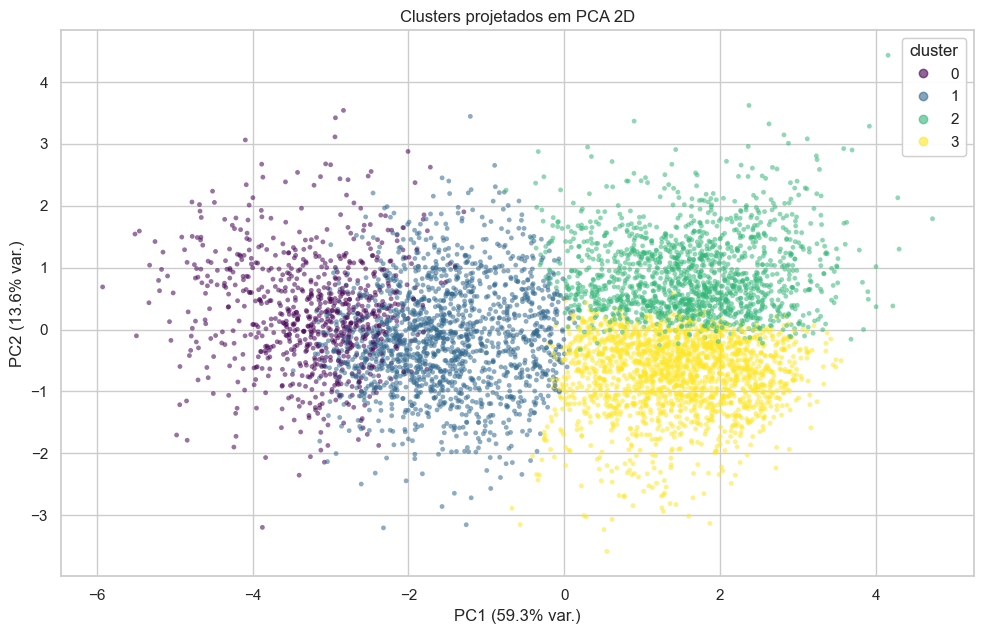

Loadings (peso de cada feature nas componentes):
                        PC1    PC2
IDHM                  0.459 -0.160
GINI                 -0.260 -0.369
LOG_PIB_PER_CAPITA    0.392  0.097
LOG_DESPESA_SAUDE_PC  0.215  0.842
T_ANALF15M           -0.449  0.201
T_AGUA                0.363 -0.241
ESPVIDA               0.434 -0.148

Variância acumulada explicada por PC1+PC2: 73.0%


In [15]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clu_scaled)

fig, ax = plt.subplots(figsize=(10, 6.5))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_clu["CLUSTER"], cmap="viridis",
    s=12, alpha=0.55, edgecolors="none",
)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("Clusters projetados em PCA 2D")
legend = ax.legend(*scatter.legend_elements(), title="cluster", loc="best")
ax.add_artist(legend)
plt.tight_layout(); plt.show()

loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=FEATURES_CLUSTER).round(3)
print("Loadings (peso de cada feature nas componentes):")
print(loadings)
print(f"\nVariância acumulada explicada por PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 10. Heatmap UF × cluster

Para cada UF, percentual dos municípios em cada cluster. Identifica quais estados são internamente homogêneos vs. heterogêneos.

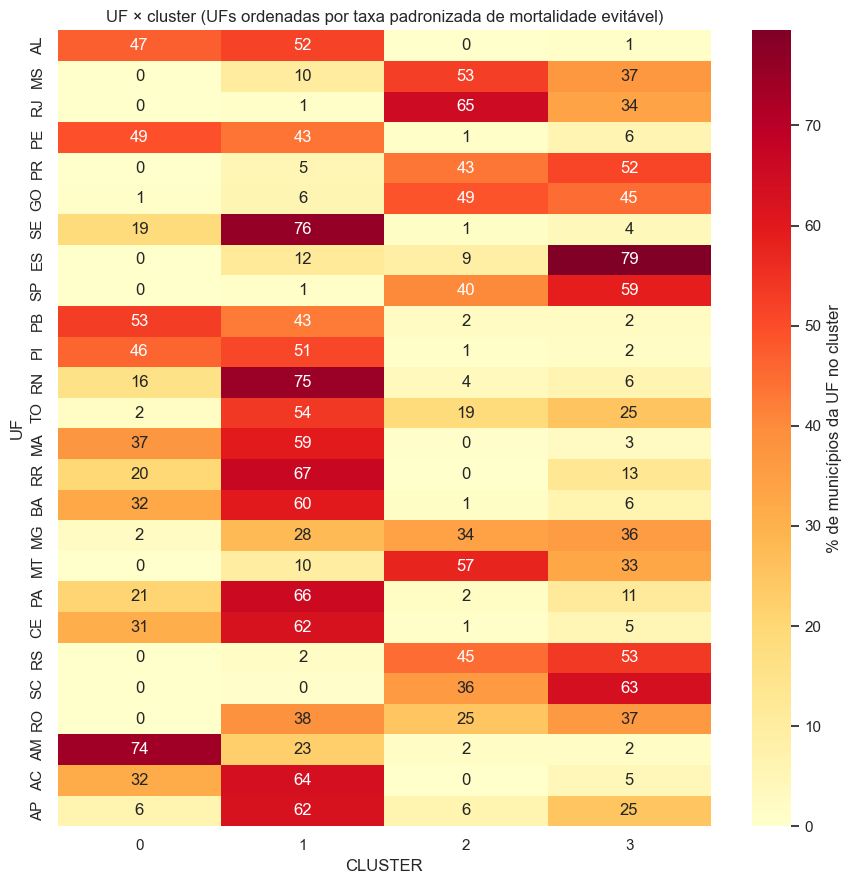

In [16]:
comp_uf = pd.crosstab(df_clu["UF"], df_clu["CLUSTER"], normalize="index") * 100

ordem_uf = (
    df_clu.groupby("UF")["TAXA_PADRONIZADA_100K"].mean()
          .sort_values(ascending=False).index.tolist()
)
comp_uf = comp_uf.reindex(ordem_uf)

fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(comp_uf, annot=True, fmt=".0f", cmap="YlOrRd",
            cbar_kws={"label": "% de municípios da UF no cluster"}, ax=ax)
ax.set_title("UF × cluster (UFs ordenadas por taxa padronizada de mortalidade evitável)")
plt.tight_layout(); plt.show()

## 11. Persistência

In [17]:
out_clu     = PROCESSED_DIR / "municipios_clusters.parquet"
out_perfil  = MODELS_DIR / "perfil_clusters.csv"

df_clu.to_parquet(out_clu, index=False)
perfil.to_csv(out_perfil)

for p in (out_clu, out_perfil):
    print(f"  {p.name:<32} → {p.stat().st_size / 1e3:>7.1f} KB")

print("\nResumo final por cluster (0 = menor IDH-M):")
print(perfil[["n_municipios", "%_pop_brasil", "taxa_bruta", "taxa_padronizada", "IDHM", "GINI", "T_AGUA"]])

  municipios_clusters.parquet      →   436.2 KB
  perfil_clusters.csv              →     0.4 KB

Resumo final por cluster (0 = menor IDH-M):
         n_municipios  %_pop_brasil  taxa_bruta  taxa_padronizada  IDHM  GINI  T_AGUA
CLUSTER                                                                              
0                 784           6.5      183.48            231.52  0.56  0.54   58.50
1                1573          15.4      208.37            249.07  0.60  0.52   83.79
2                1430           8.8      247.51            239.62  0.70  0.45   91.66
3                1774          69.3      243.10            250.55  0.72  0.48   94.27


---

**Leitura dos clusters:**

A renumeração por IDH-M garante que **cluster 0 = perfil mais vulnerável** (menor IDH-M) e **cluster K-1 = mais desenvolvido**. Cruzando com o perfil socioeconômico (tabela e heatmap acima):

- **Clusters 0–1 (vulneráveis)** — IDH baixo, Gini alto, analfabetismo elevado, saneamento precário; concentrados no Norte e Nordeste.
- **Clusters 2–3 (desenvolvidos)** — IDH alto, saneamento quase universal, despesa em saúde acima da média; predominantemente Sudeste e Sul.

**Taxa bruta vs padronizada:** a tabela de perfil mostra as duas. Pela taxa **bruta**, os clusters desenvolvidos parecem ter mortalidade *maior* — artefato da população mais envelhecida. Pela taxa **padronizada por idade** (notebook 06), o gradiente se corrige e os clusters vulneráveis passam a ter mortalidade comparável ou superior, coerente com a tese. O **teste ANOVA** confirma diferença significativa entre clusters em ambas as medidas.

**Próximos passos:**
- **Notebook 05 (mineração)** — para cada cluster, top causas CID-10 e padrão de grupos LBCE dominantes.
- **Notebook 06 (padronização)** — detalhamento da taxa padronizada por idade e seu impacto na regressão.